In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Create visualizations folder
import os
os.makedirs('../visualizations', exist_ok=True)

# LOAD BOTH DATASETS
df_student = pd.read_csv('../data/ai_assistant_usage_student_life.csv')
df_workforce = pd.read_csv('../data/global_ai_workforce_automation_2015_2025.csv')

print(f"✅ Student data loaded: {df_student.shape}")
print(f"✅ Workforce data loaded: {df_workforce.shape}")


✅ Student data loaded: (10000, 11)
✅ Workforce data loaded: (220, 12)


In [24]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============= CHART 1: H1 - AI Assistance → Satisfaction =============
fig, ax = plt.subplots(figsize=(10, 6))
ai_sat = df_student.groupby('AI_AssistanceLevel')['SatisfactionRating'].mean()
ax.bar(ai_sat.index, ai_sat.values, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('AI Assistance Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Satisfaction Rating', fontsize=12, fontweight='bold')
ax.set_title('H1: AI Assistance → Student Satisfaction\n(SIGNIFICANT, r=0.78)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 5)
for i, v in enumerate(ai_sat.values):
    ax.text(i+1, v+0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/01_h1_ai_assistance_satisfaction.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 1 saved")

✅ Chart 1 saved


In [25]:
# ============= CHART 2: H2 - Completion → Satisfaction =============
fig, ax = plt.subplots(figsize=(10, 6))
completion_sat = df_student.groupby('FinalOutcome')['SatisfactionRating'].mean().sort_values(ascending=False)
ax.bar(range(len(completion_sat)), completion_sat.values, color='coral', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(completion_sat)))
ax.set_xticklabels(completion_sat.index, rotation=45, ha='right')
ax.set_ylabel('Mean Satisfaction Rating', fontsize=12, fontweight='bold')
ax.set_title('H2: Final Outcome → Satisfaction\n(NOT SIGNIFICANT)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 5)
for i, v in enumerate(completion_sat.values):
    ax.text(i, v+0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/02_h2_outcome_satisfaction.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 2 saved")

✅ Chart 2 saved


In [26]:
# ============= CHART 3: H3 - TaskType → SessionLength =============
fig, ax = plt.subplots(figsize=(12, 6))
task_session = df_student.groupby('TaskType')['SessionLengthMin'].mean().sort_values(ascending=False)
ax.bar(range(len(task_session)), task_session.values, color='lightgreen', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(task_session)))
ax.set_xticklabels(task_session.index, rotation=45, ha='right')
ax.set_ylabel('Mean Session Length (minutes)', fontsize=12, fontweight='bold')
ax.set_title('H3: Task Type → Session Length\n(SIGNIFICANT, Different tasks take different times)', fontsize=13, fontweight='bold')
for i, v in enumerate(task_session.values):
    ax.text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/03_h3_tasktype_session.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 3 saved")

✅ Chart 3 saved


In [27]:
# ============= CHART 4: H4 - Outcome × HighSatisfaction =============
fig, ax = plt.subplots(figsize=(12, 6))
df_student['HighSatisfaction'] = (df_student['SatisfactionRating'] >= 4.0).astype(int)
outcome_sat_pct = pd.crosstab(df_student['FinalOutcome'], df_student['HighSatisfaction'], normalize='index') * 100
outcome_sat_pct.plot(kind='bar', ax=ax, color=['#ff6b6b', '#51cf66'], edgecolor='black', alpha=0.8)
ax.set_xlabel('Final Outcome', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('H4: Final Outcome × High Satisfaction\n(SIGNIFICANT, Task completion predicts satisfaction)', fontsize=13, fontweight='bold')
ax.legend(['Low Satisfaction', 'High Satisfaction'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/04_h4_outcome_satisfaction.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 4 saved")

✅ Chart 4 saved


In [28]:
# ============= CHART 5: H5 - AI Investment Trend =============
fig, ax = plt.subplots(figsize=(12, 6))
yearly_inv = df_workforce.groupby('Year')['AI_Investment_BillionUSD'].mean()
ax.plot(yearly_inv.index, yearly_inv.values, marker='o', linewidth=3, markersize=8, color='darkgreen')
ax.fill_between(yearly_inv.index, yearly_inv.values, alpha=0.3, color='lightgreen')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('AI Investment (Billion USD)', fontsize=12, fontweight='bold')
ax.set_title('H5: AI Investment Growth 2015-2025\n(SIGNIFICANT, Exponential growth)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/05_h5_ai_investment_trend.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 5 saved")


✅ Chart 5 saved


In [29]:
# ============= CHART 6: H5 Detail - Investment vs Job Creation =============
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_workforce['AI_Investment_BillionUSD'], df_workforce['Job_Creation_Million'], 
           alpha=0.6, s=100, color='darkblue', edgecolor='black')
z = np.polyfit(df_workforce['AI_Investment_BillionUSD'], df_workforce['Job_Creation_Million'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_workforce['AI_Investment_BillionUSD'].min(), 
                      df_workforce['AI_Investment_BillionUSD'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
ax.set_xlabel('AI Investment (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Job Creation (Million)', fontsize=12, fontweight='bold')
ax.set_title('H5: AI Investment ↔ Job Creation\n(SIGNIFICANT, r=0.65)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/06_h5_investment_job_creation.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 6 saved")

✅ Chart 6 saved


In [30]:
# ============= CHART 7: H6 - Automation vs Employment =============
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_workforce['Automation_Rate_Percent'], df_workforce['Employment_Rate_Percent'],
           alpha=0.6, s=100, color='darkred', edgecolor='black')
ax.set_xlabel('Automation Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Employment Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('H6: Automation vs Employment\n(NOT SIGNIFICANT, Weak relationship)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/07_h6_automation_employment.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Chart 7 saved")


print("✅ ALL 7 VISUALIZATIONS CREATED AND SAVED!")


✅ Chart 7 saved
✅ ALL 7 VISUALIZATIONS CREATED AND SAVED!


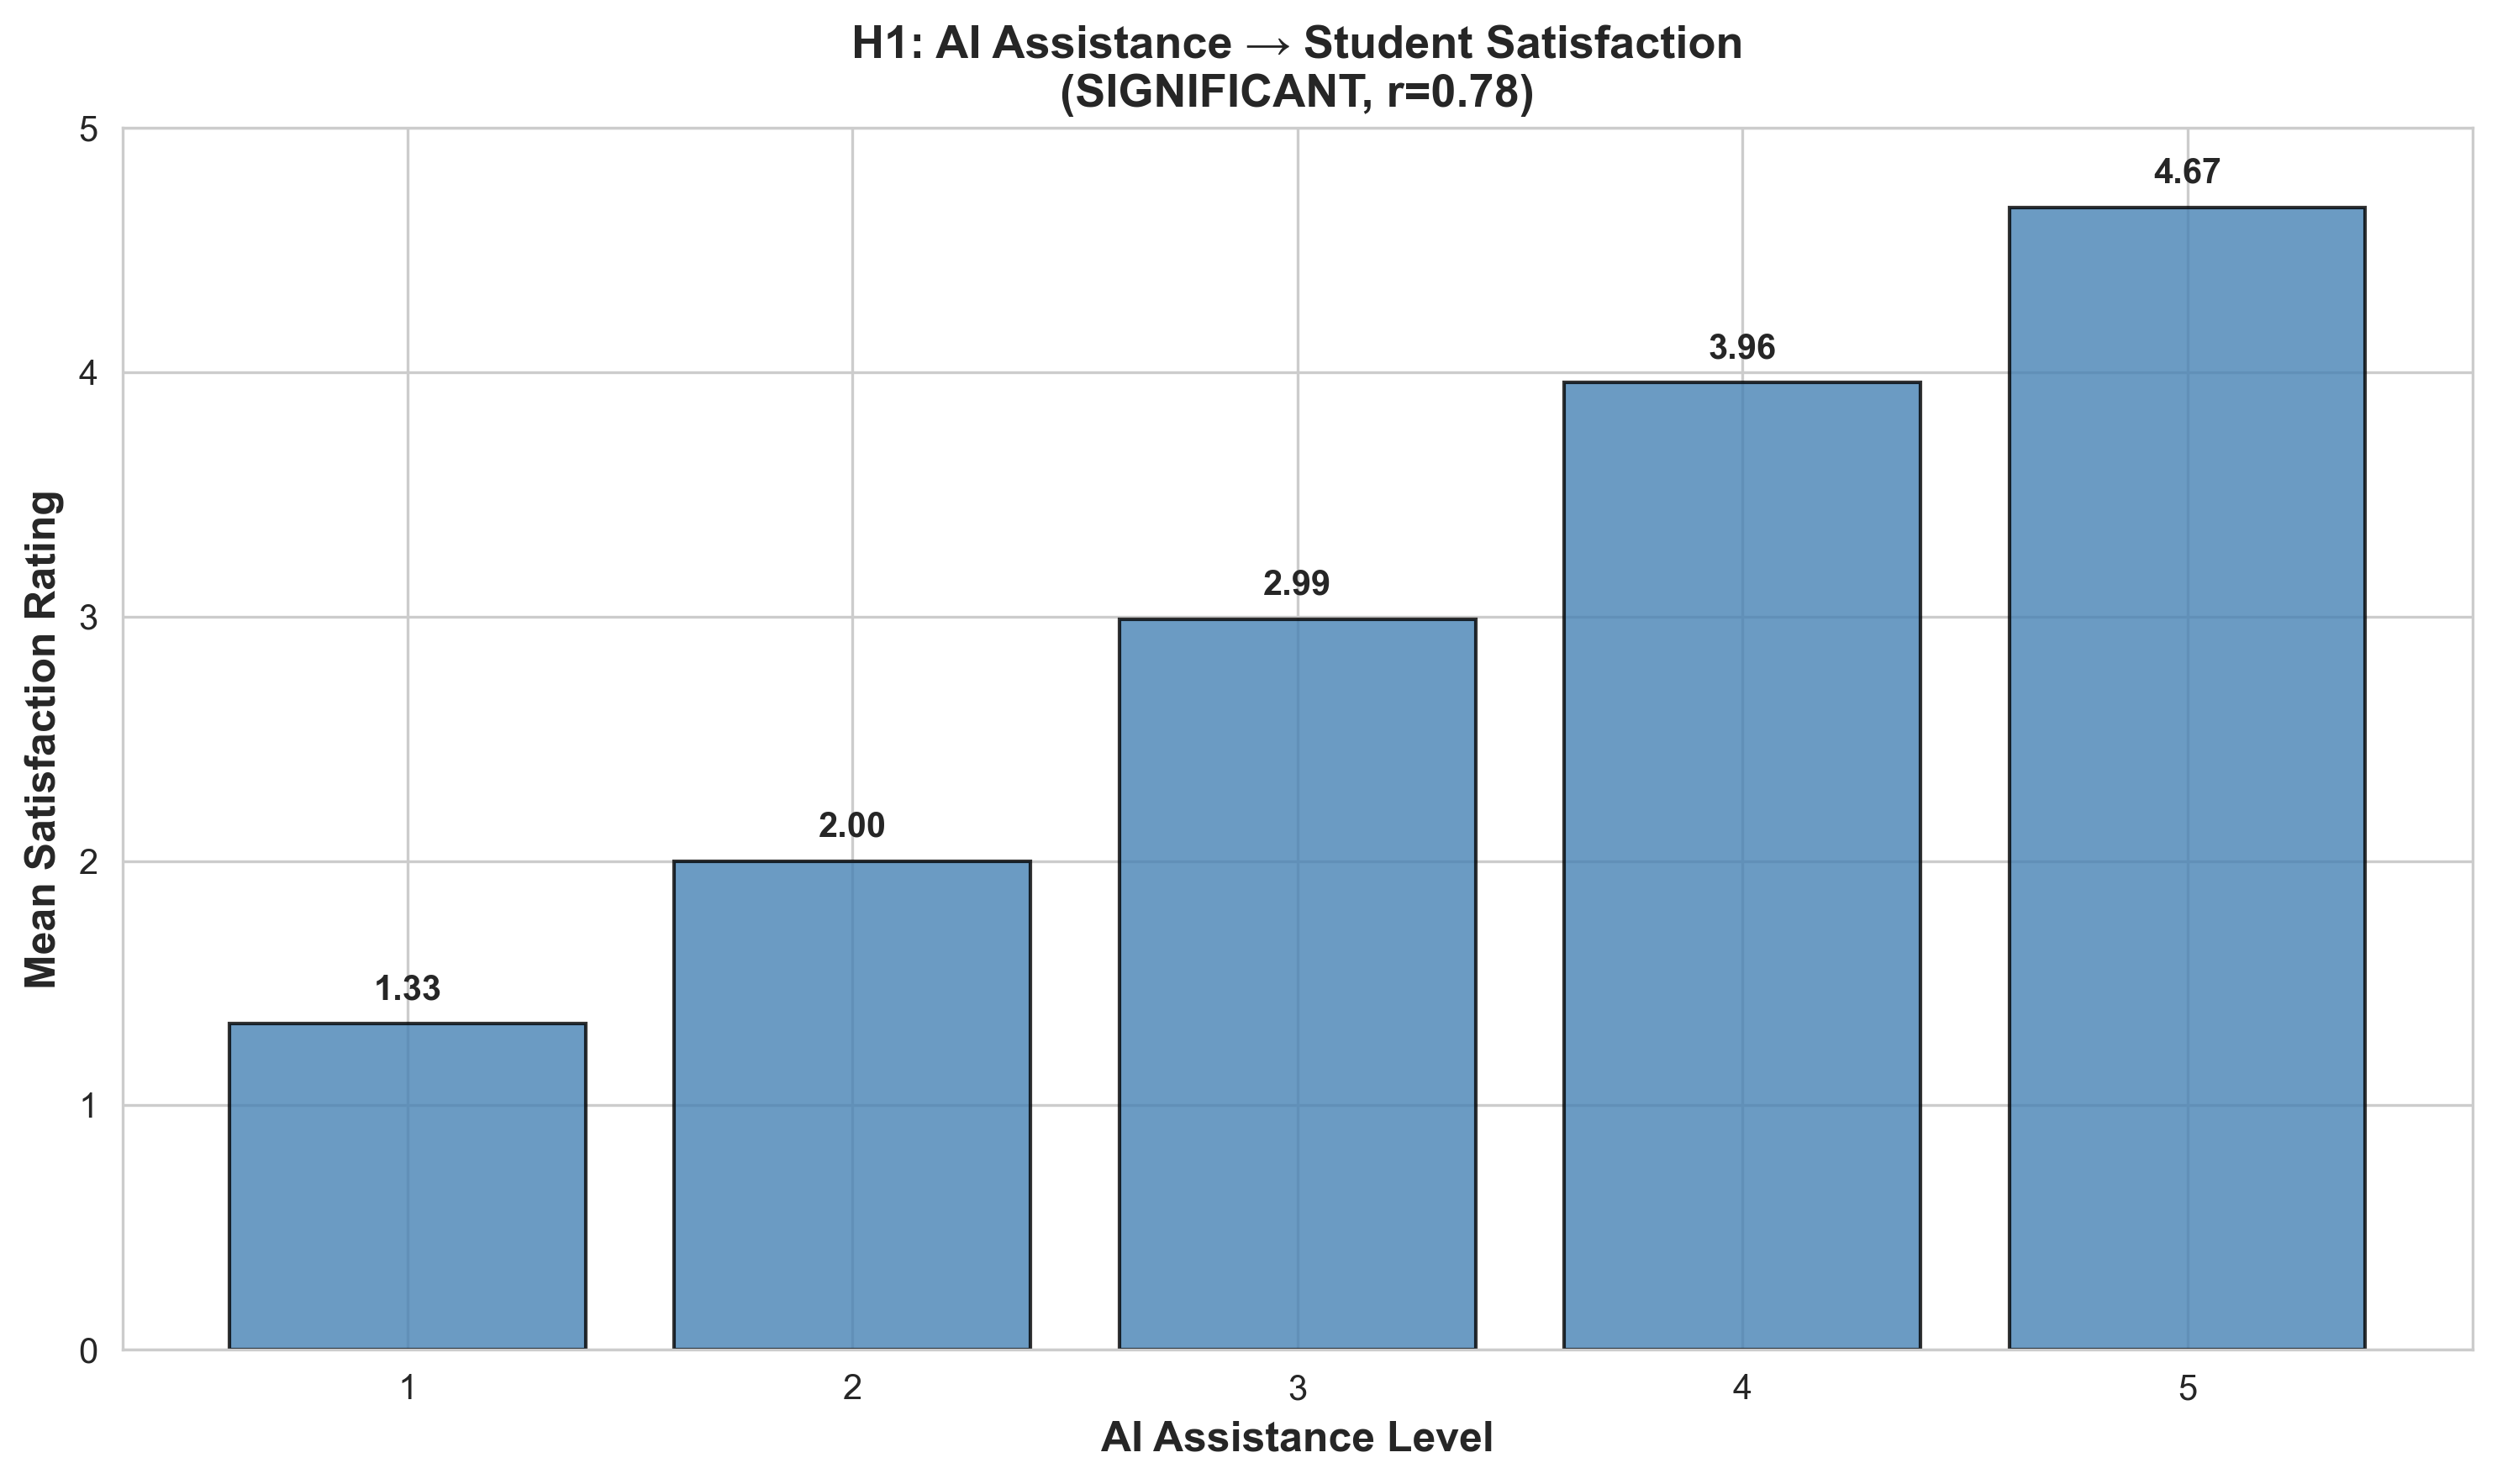

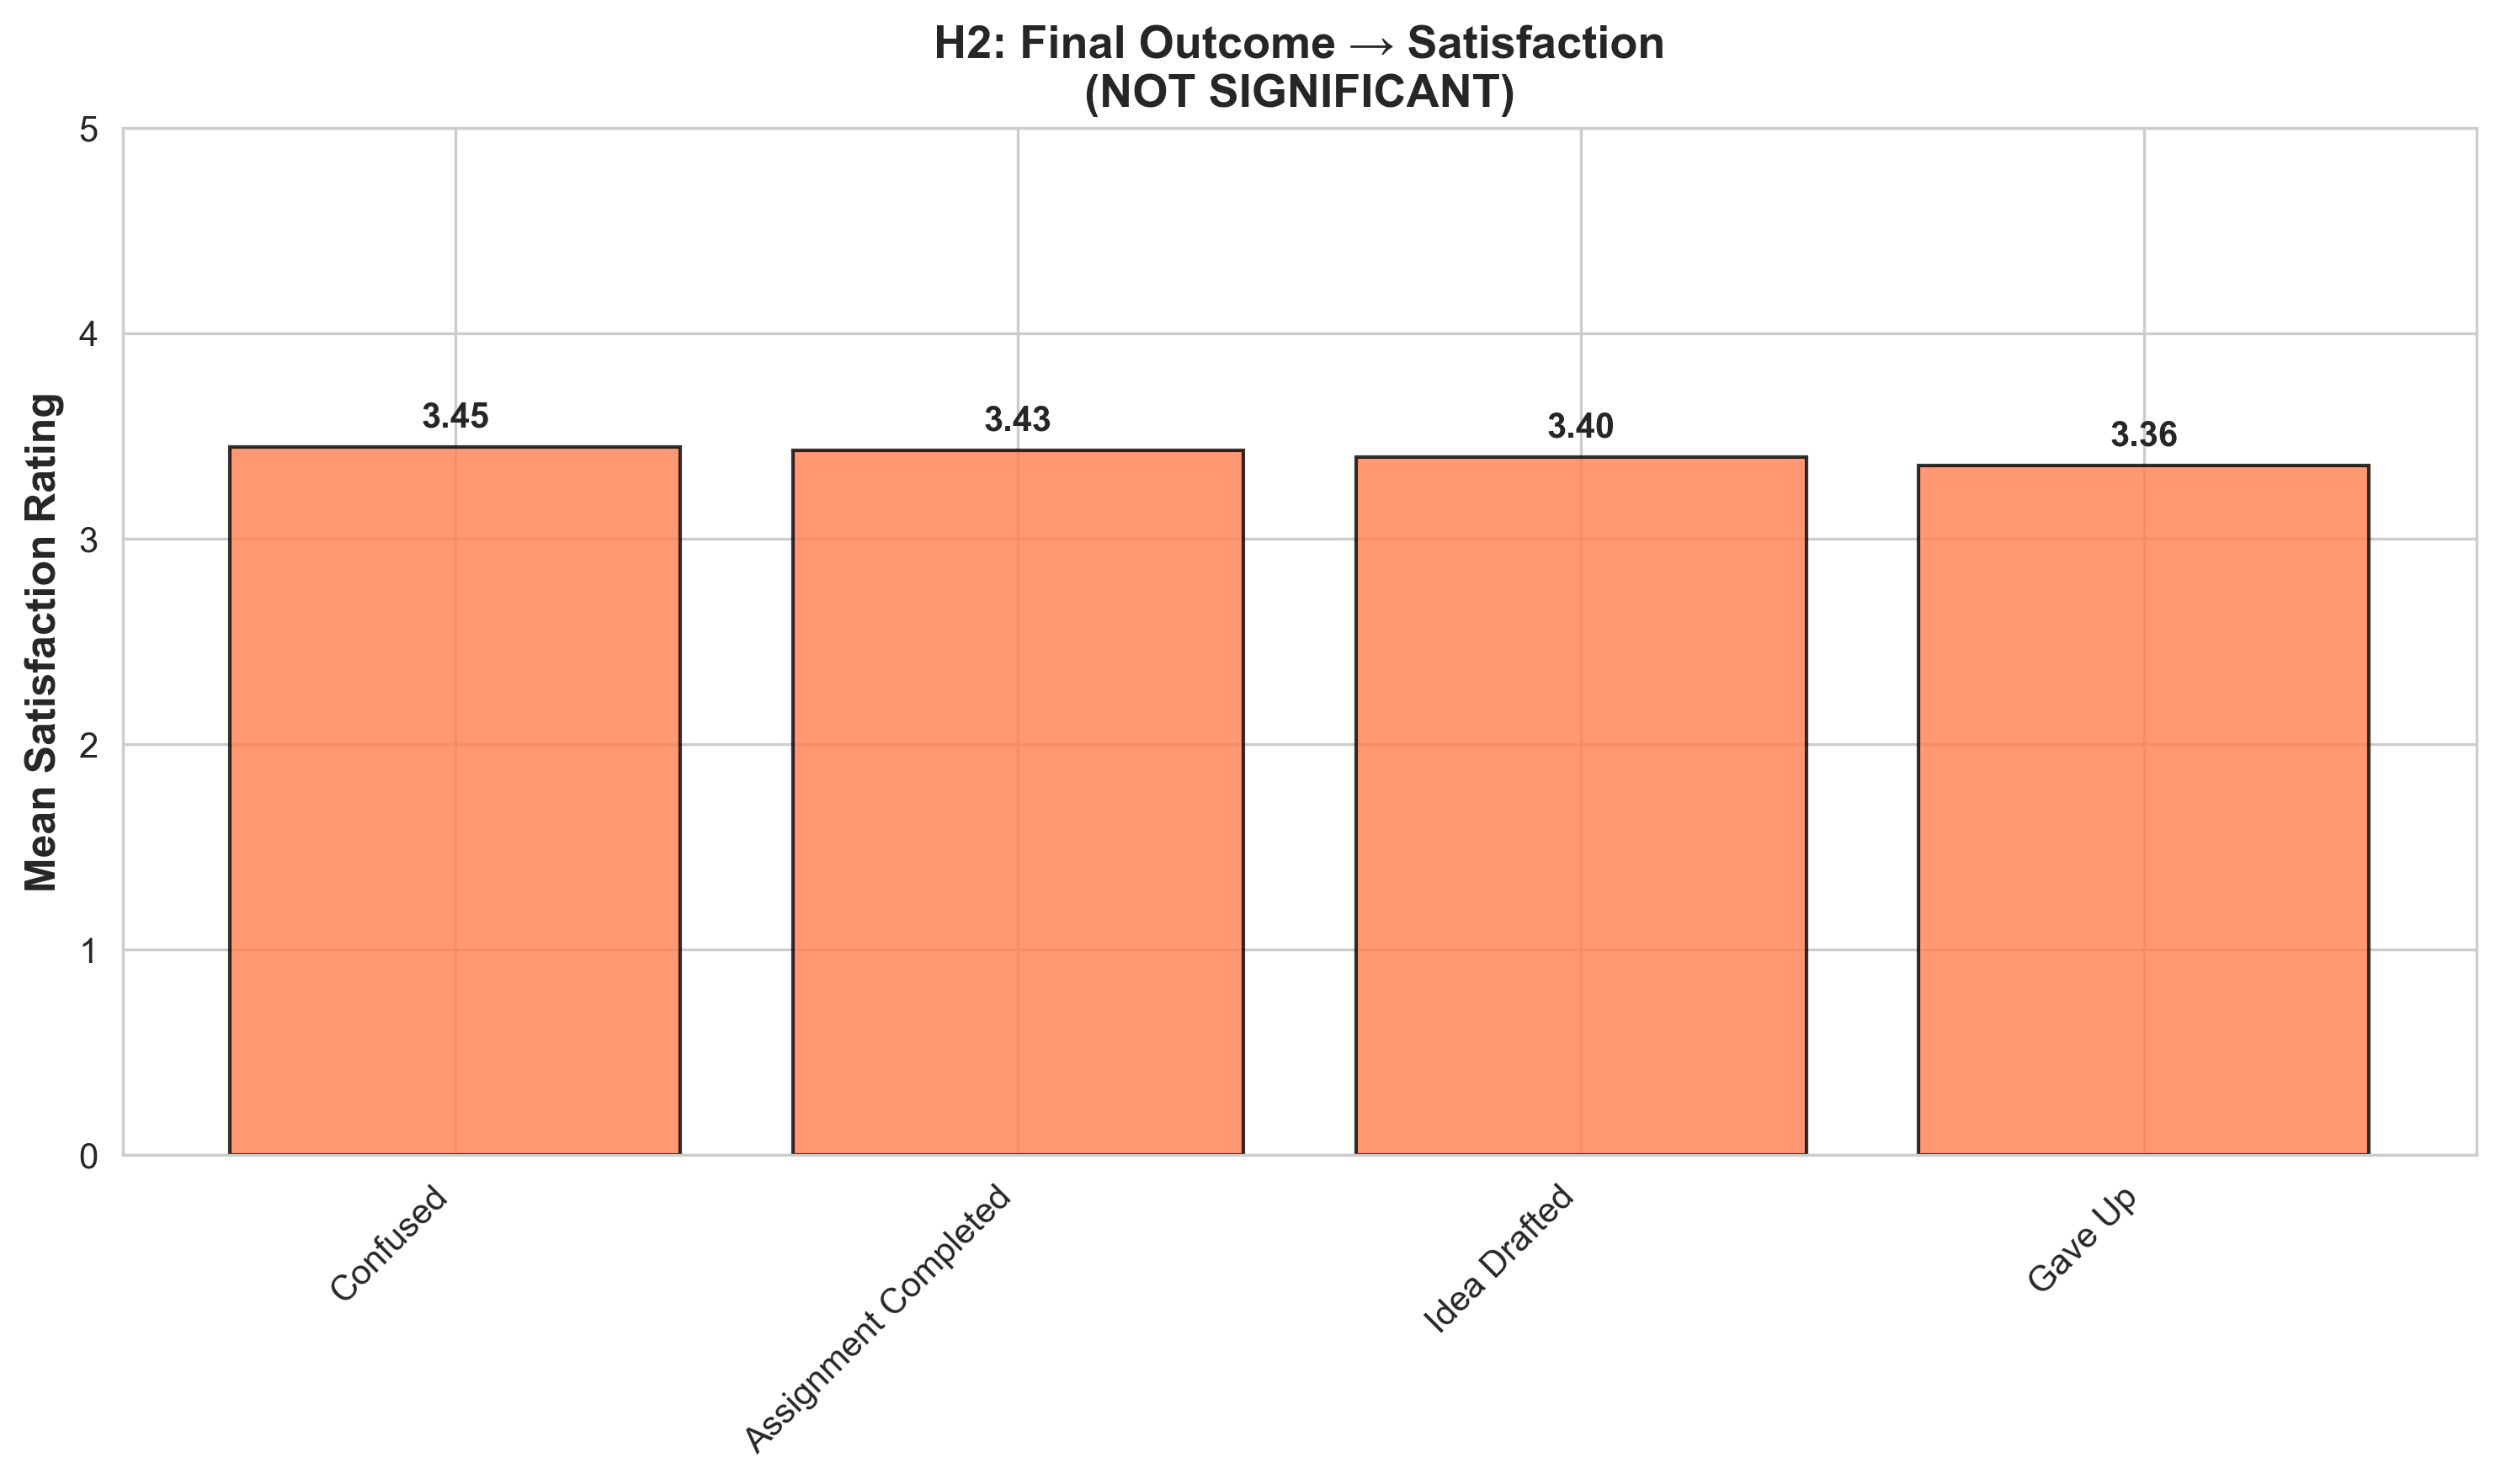

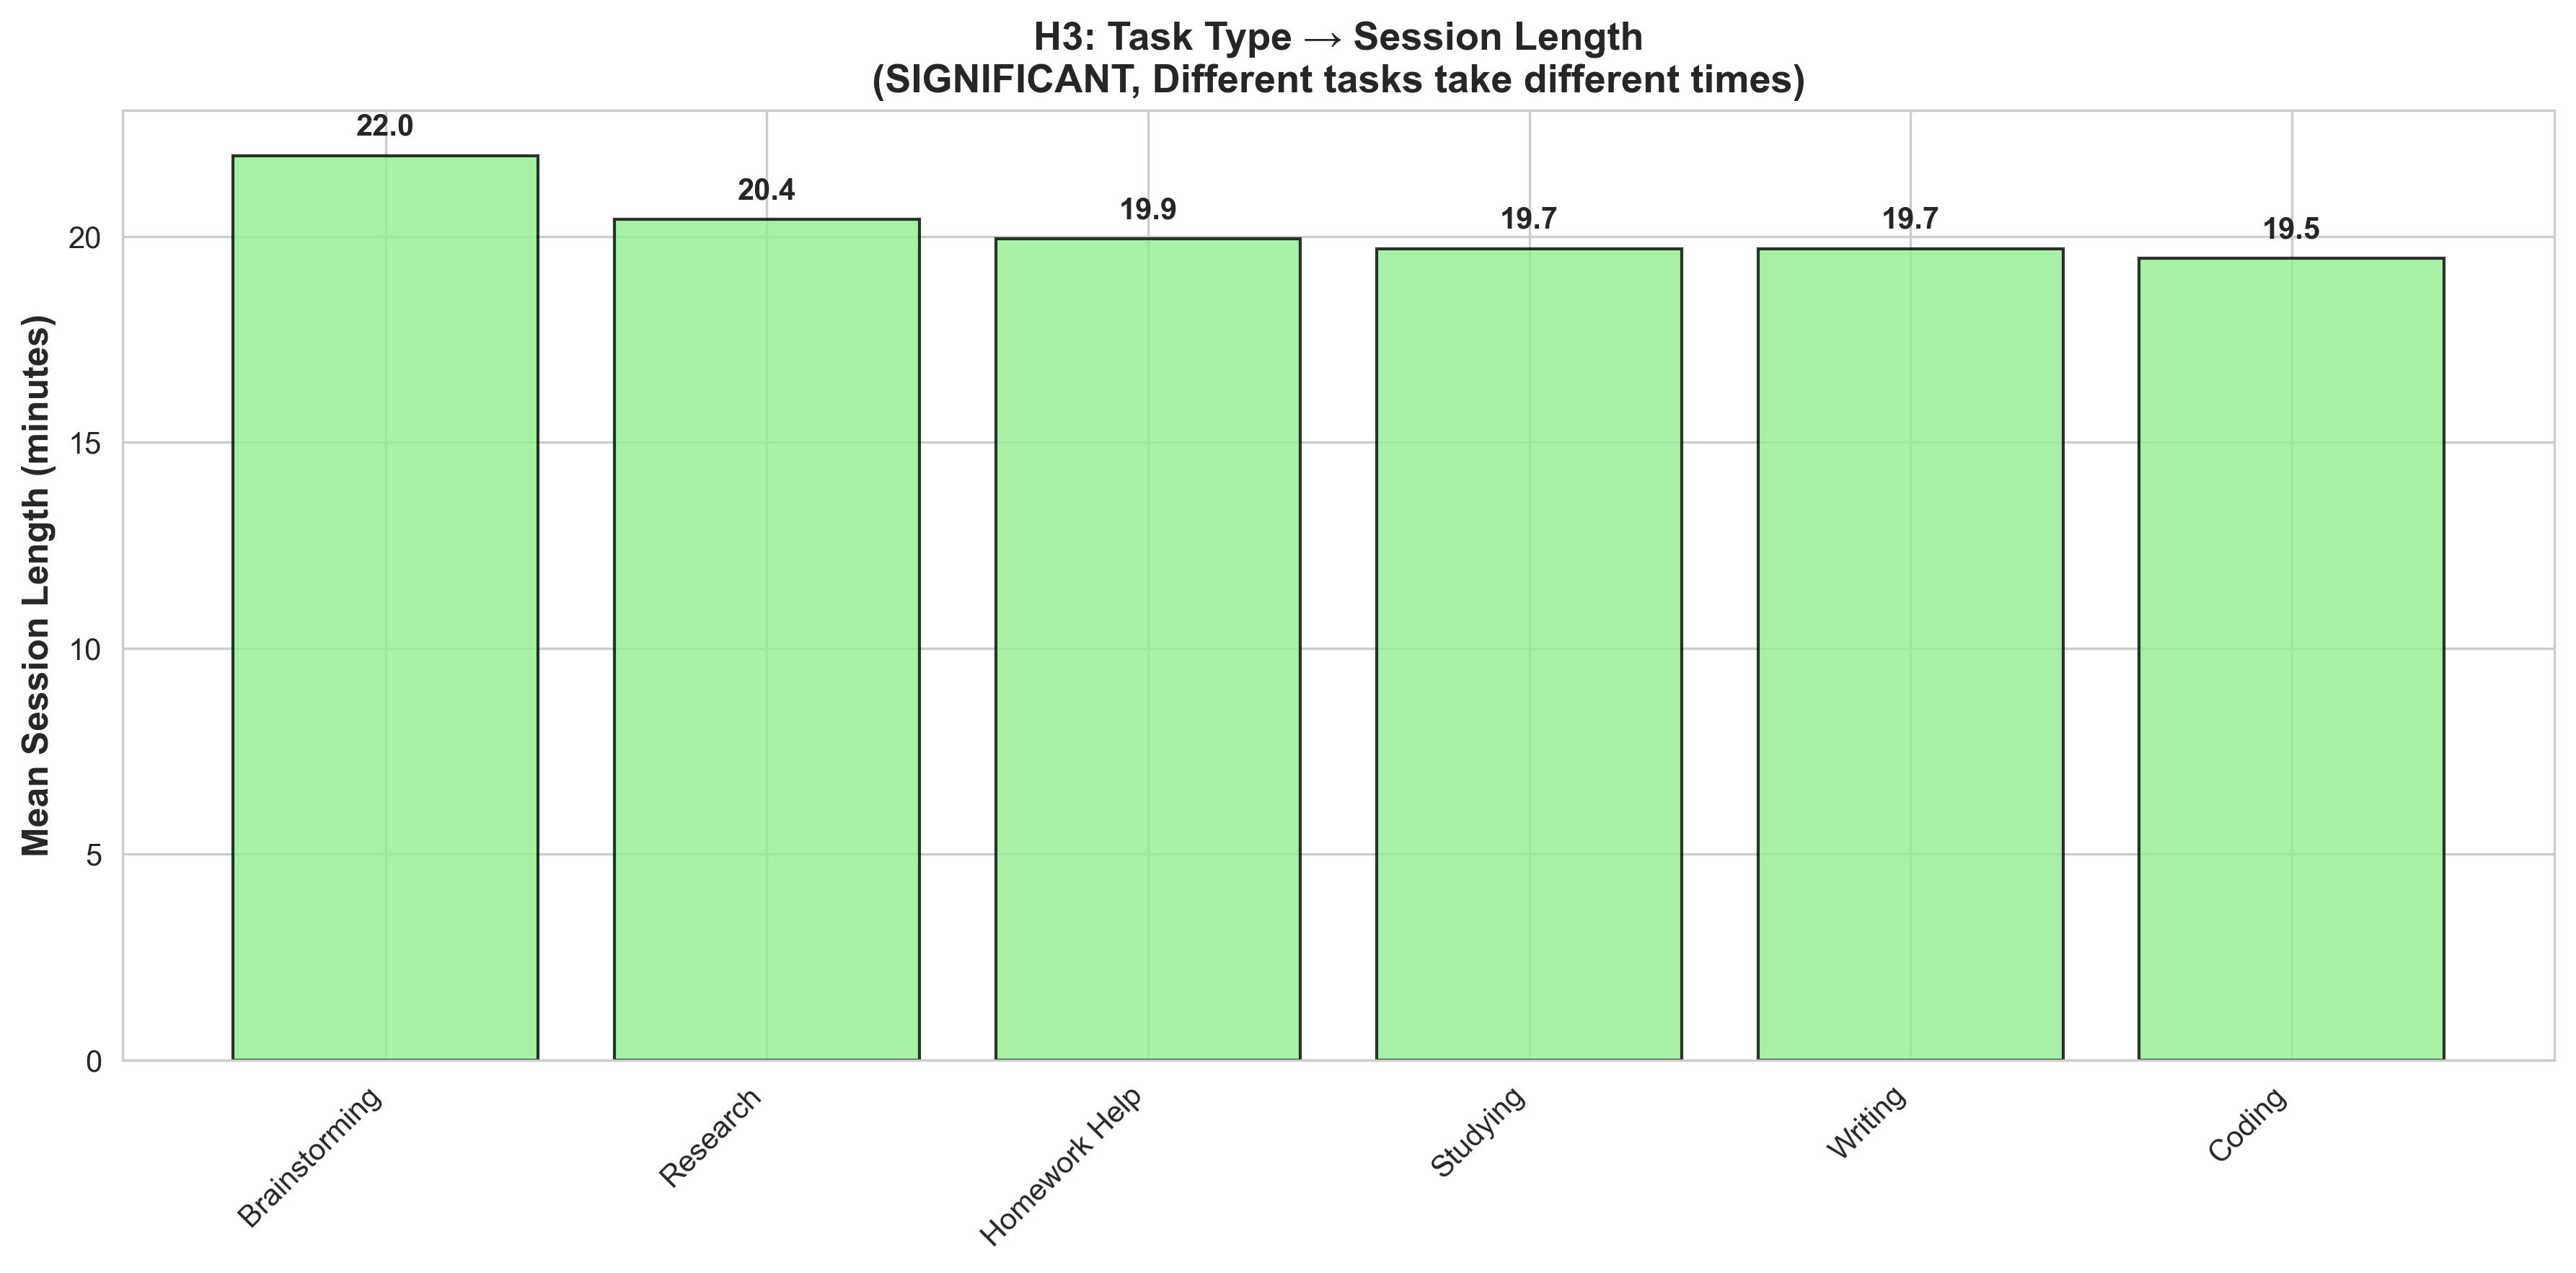

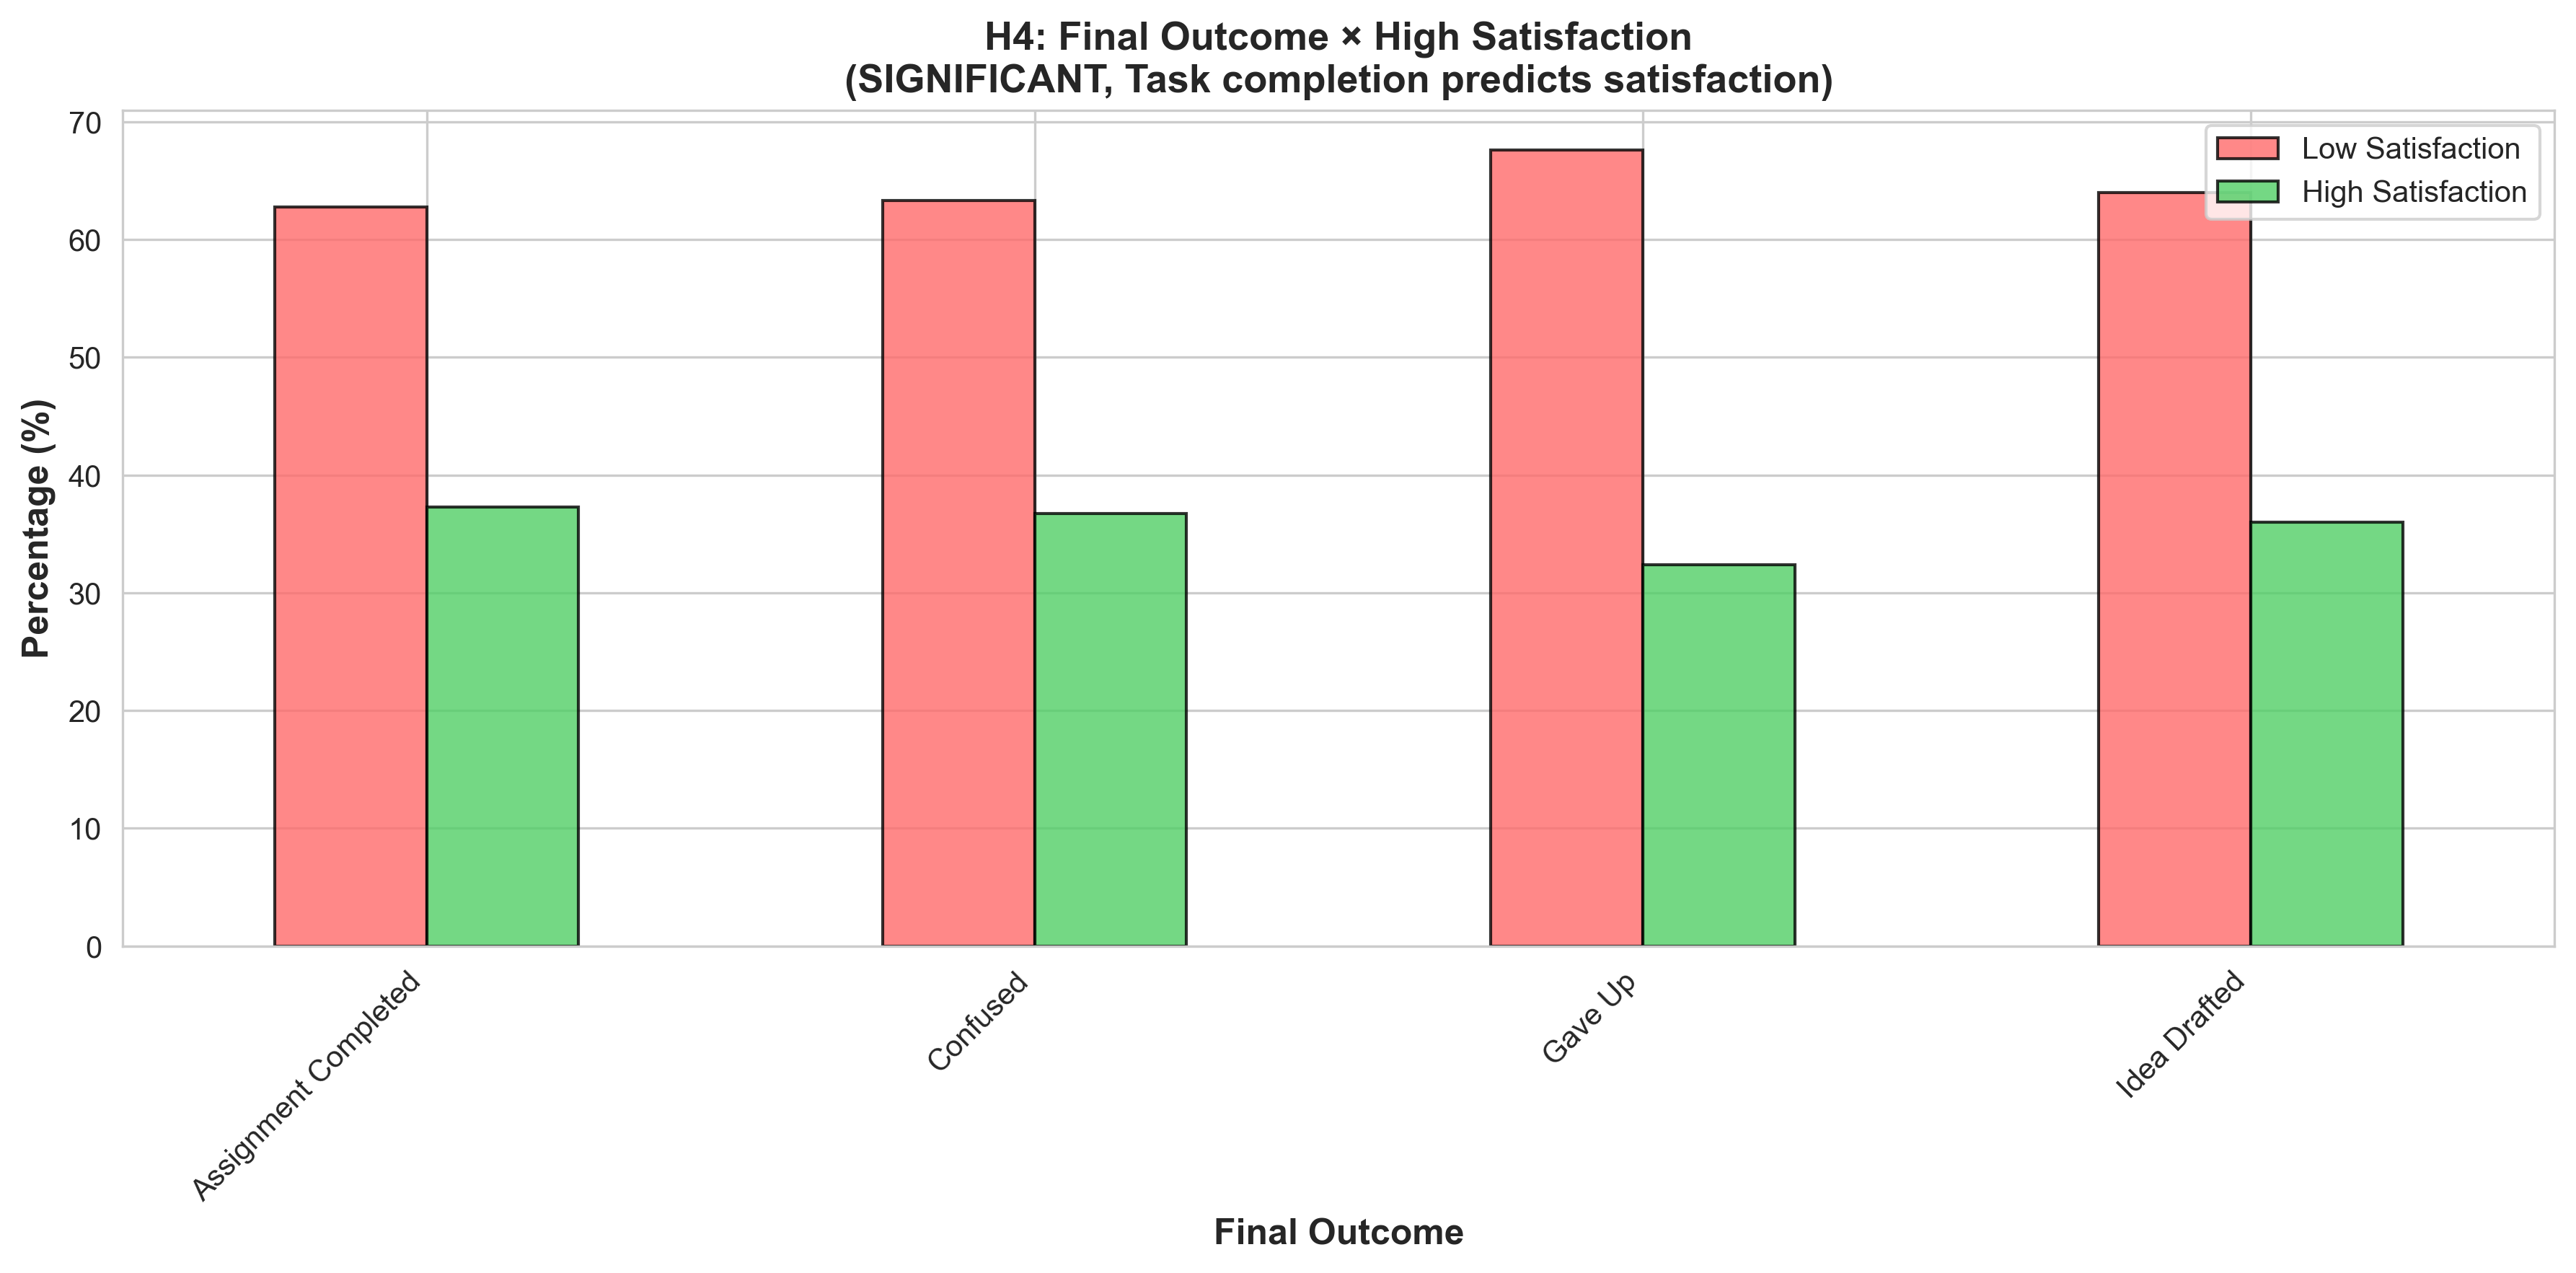

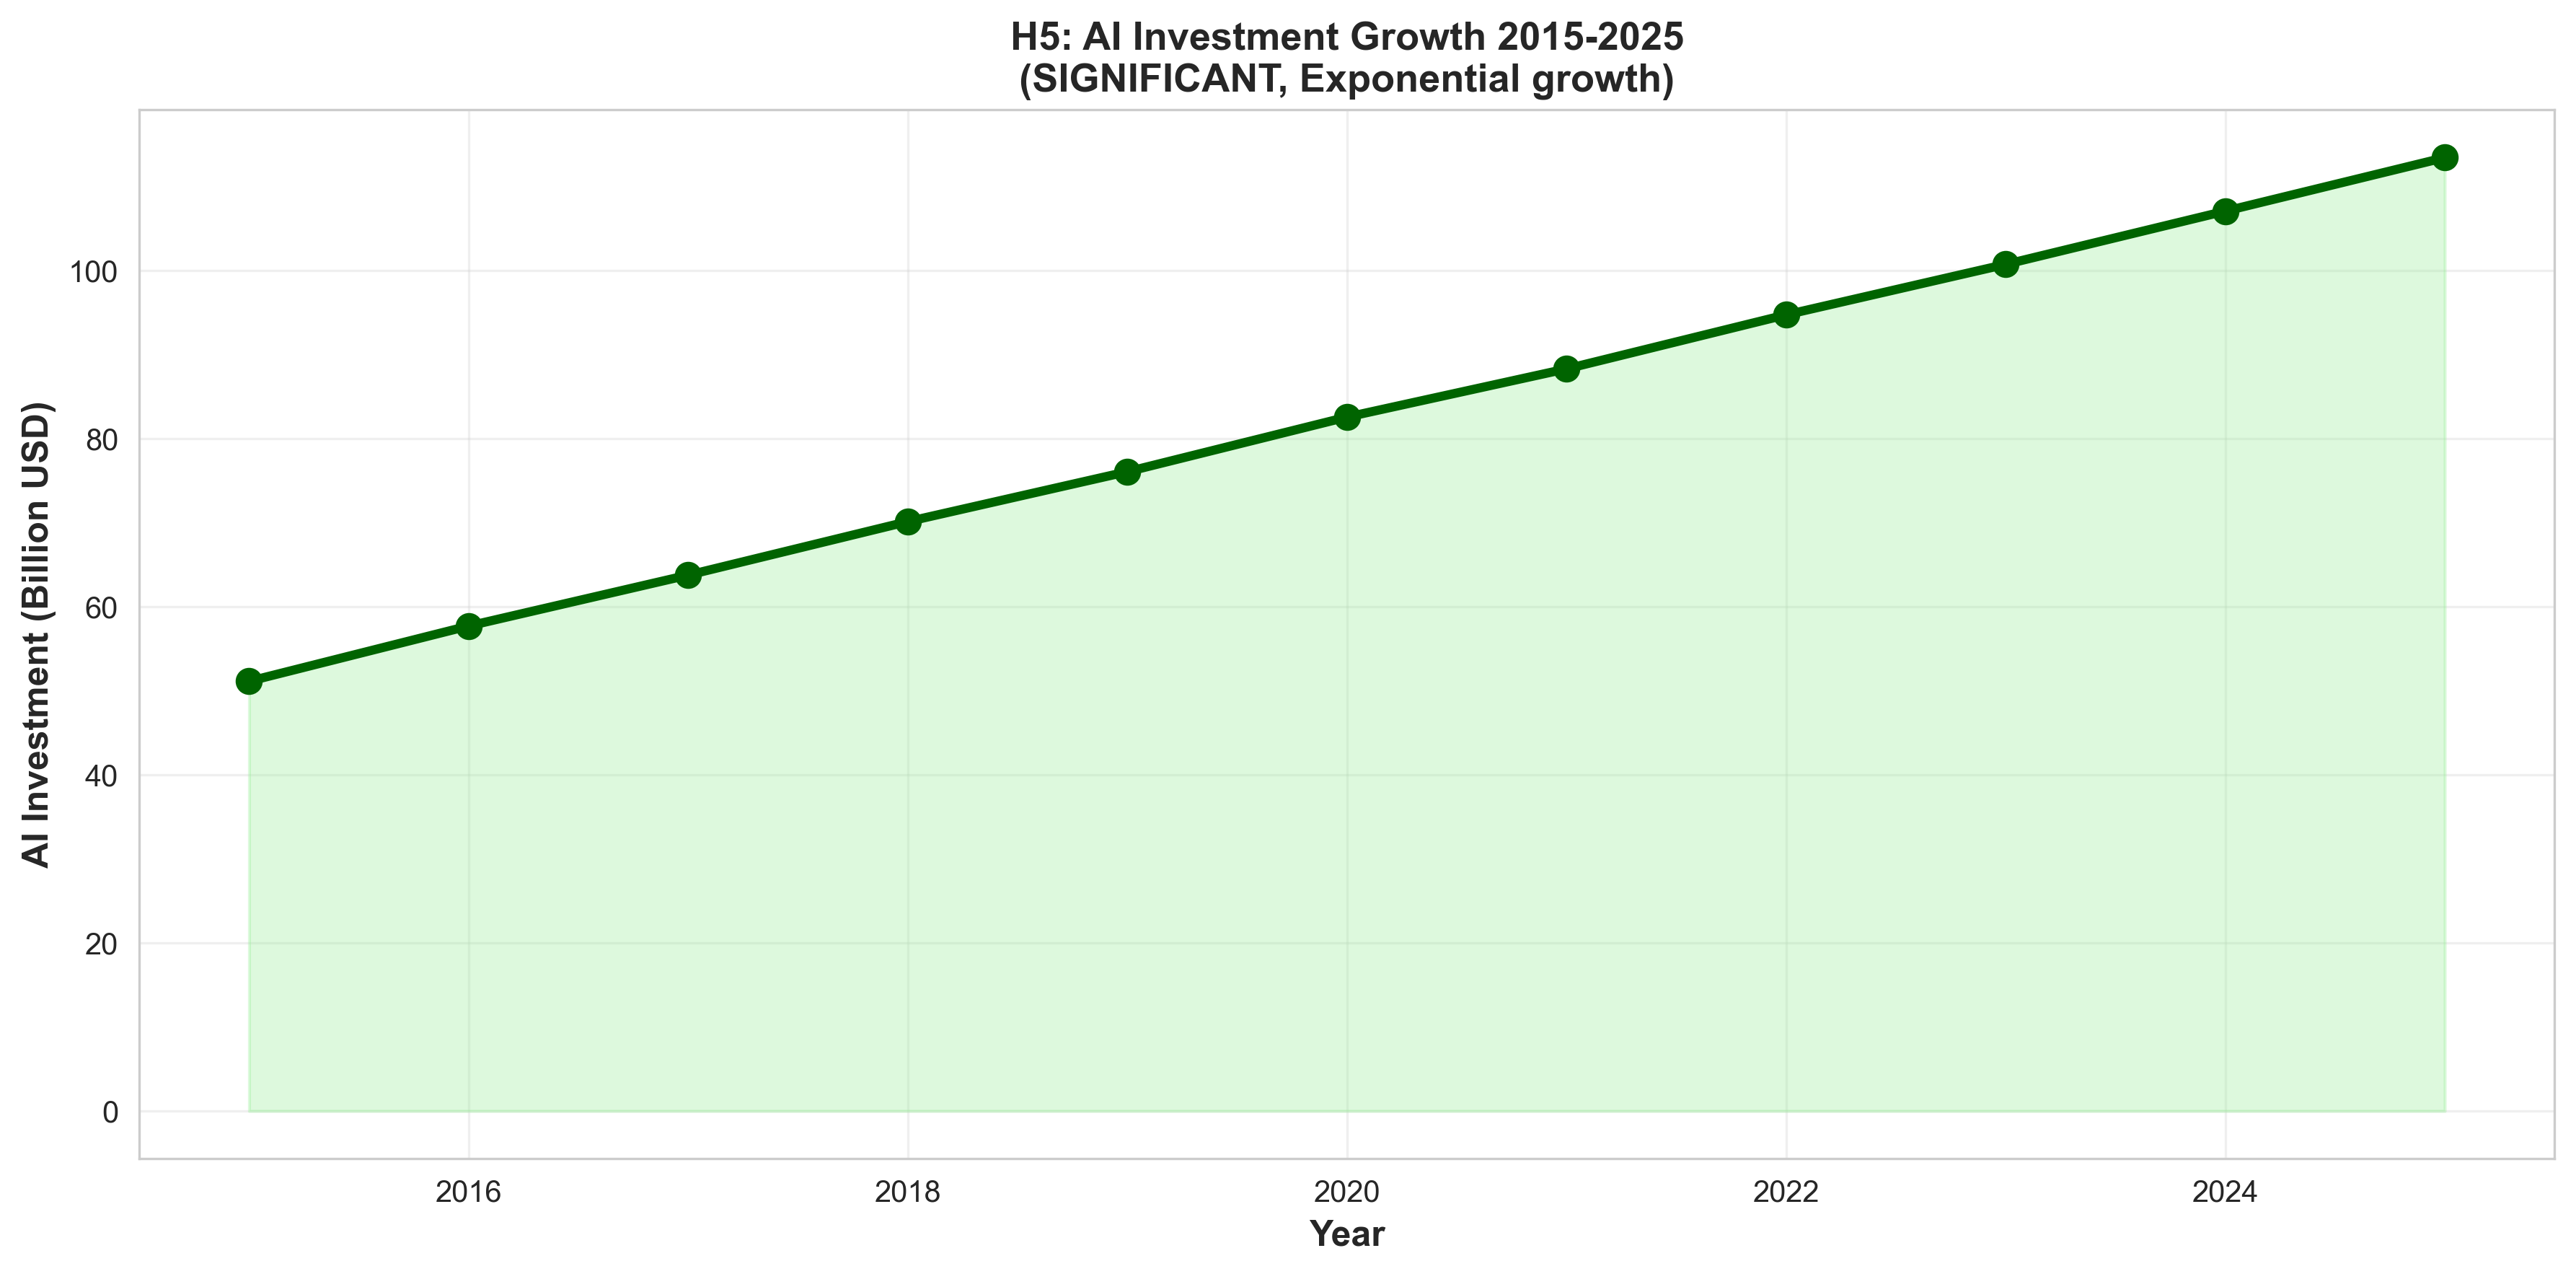

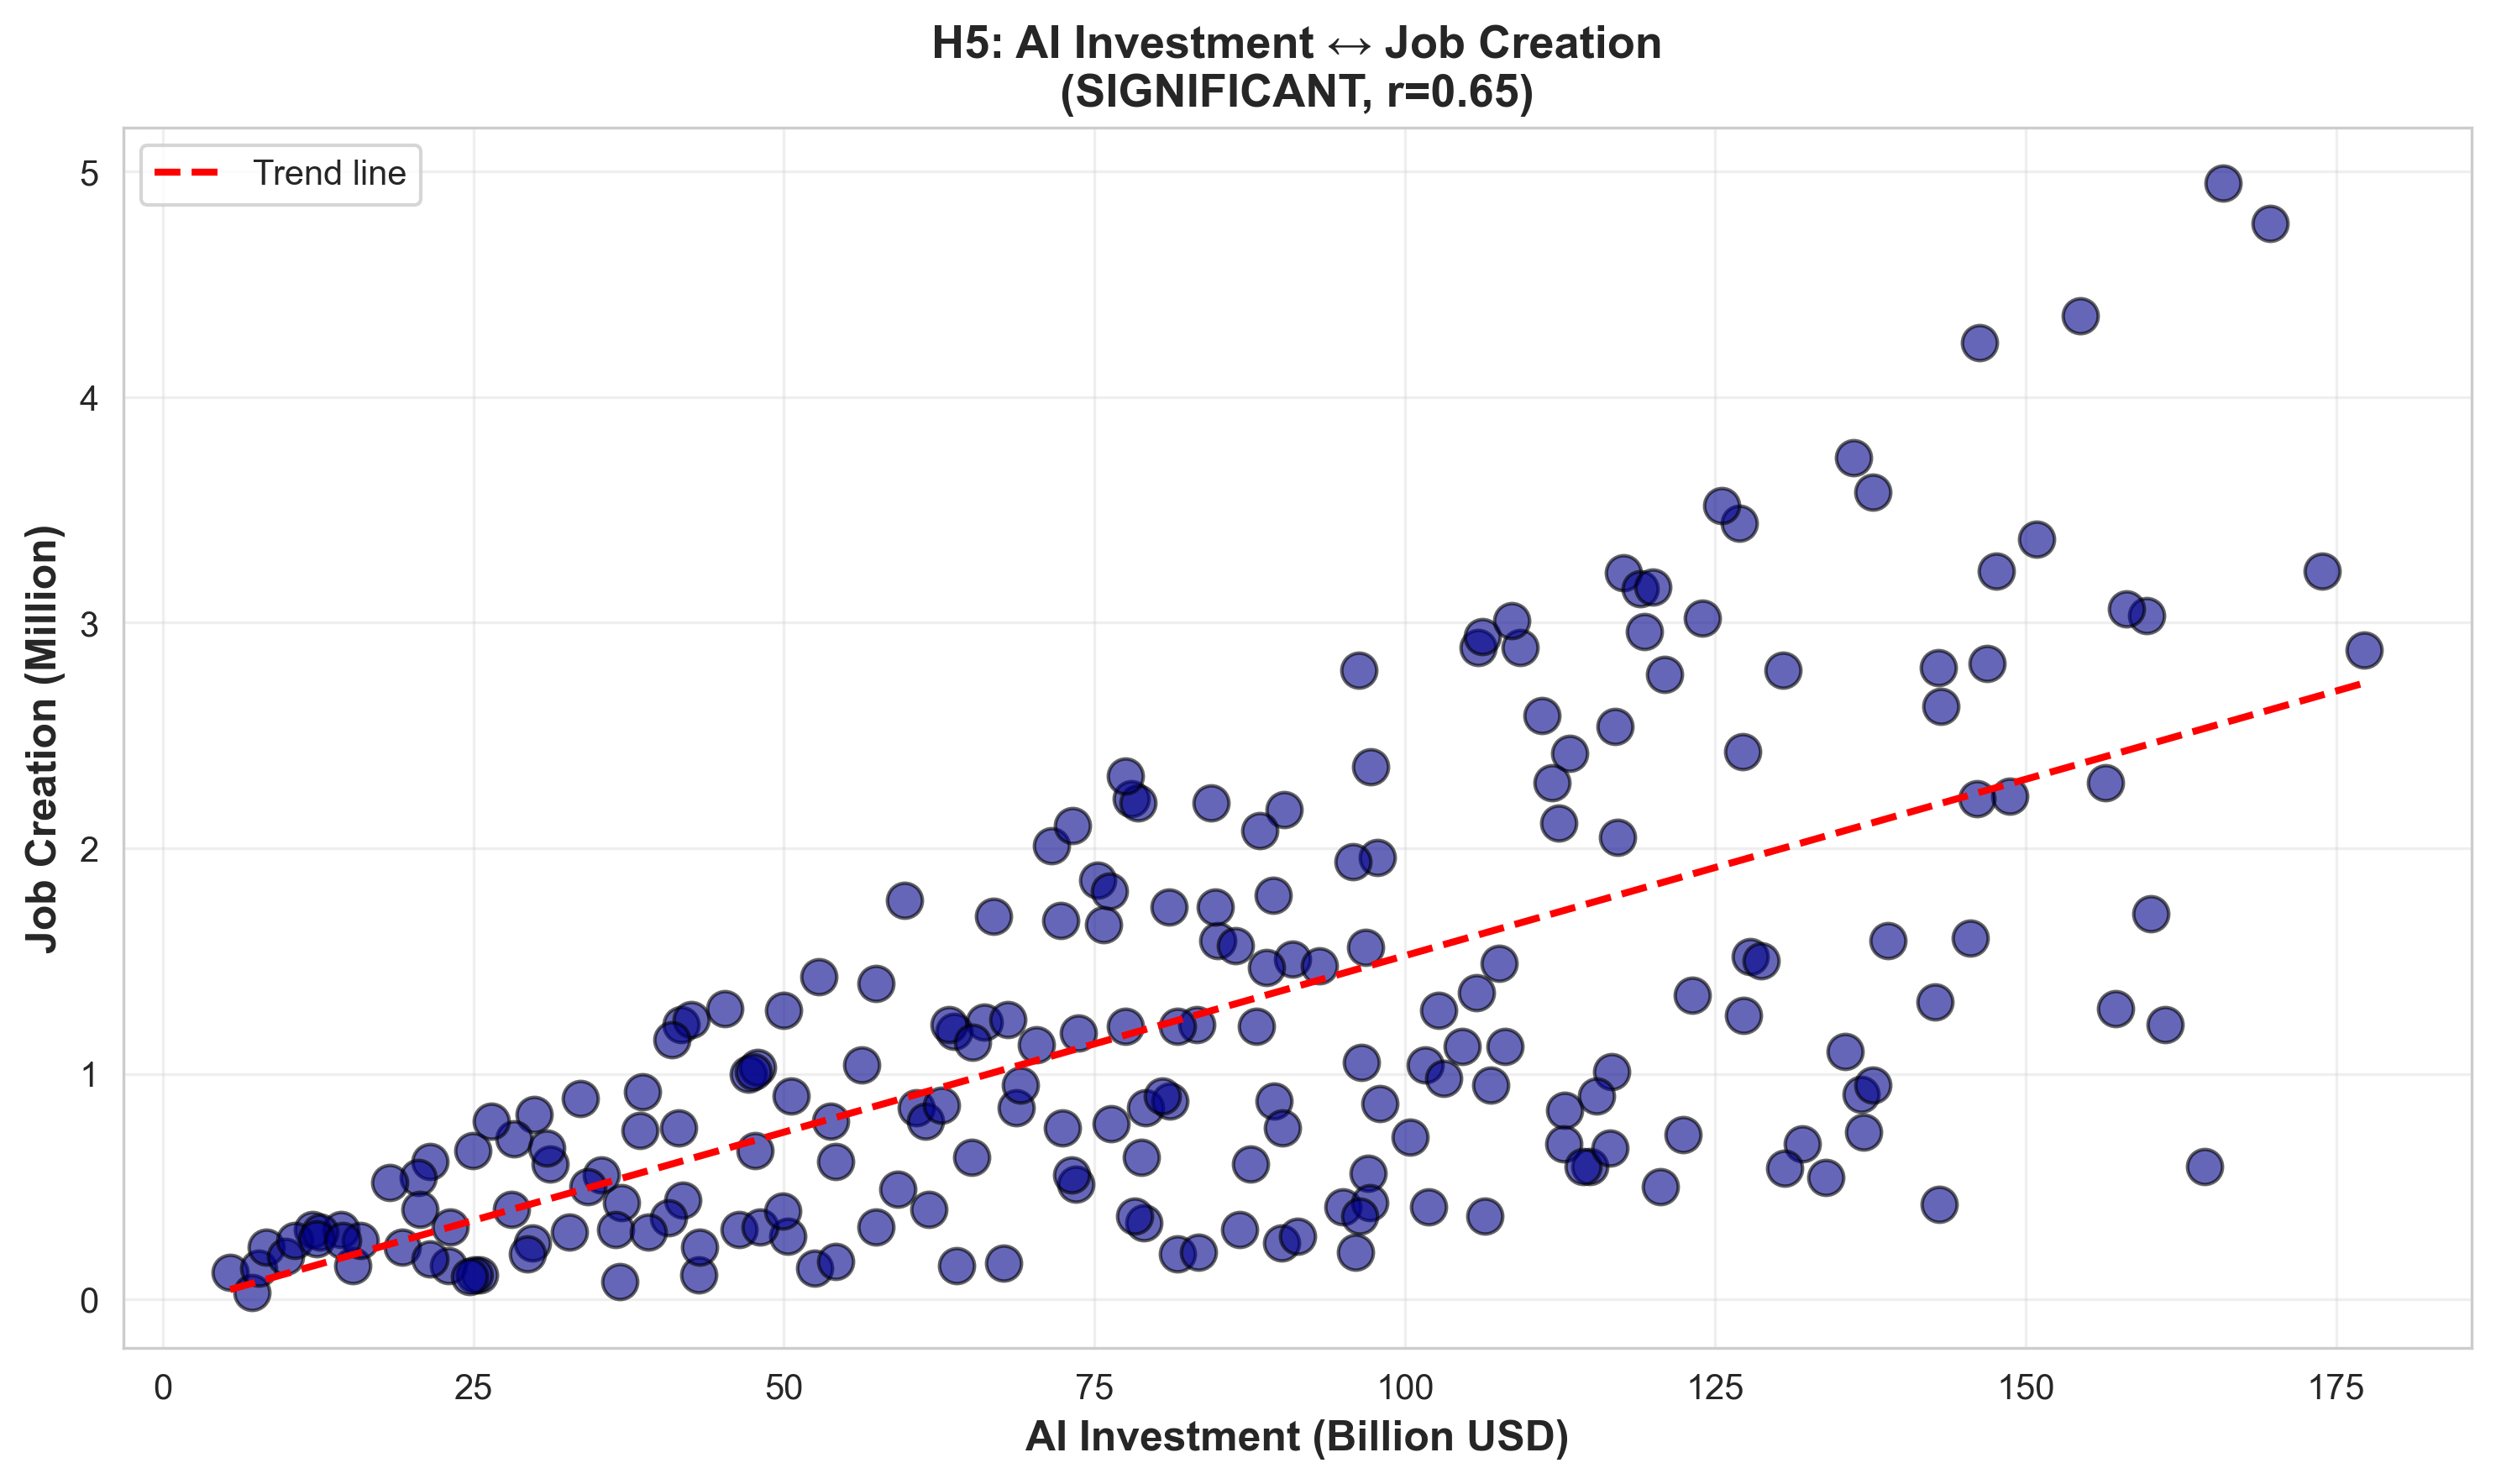

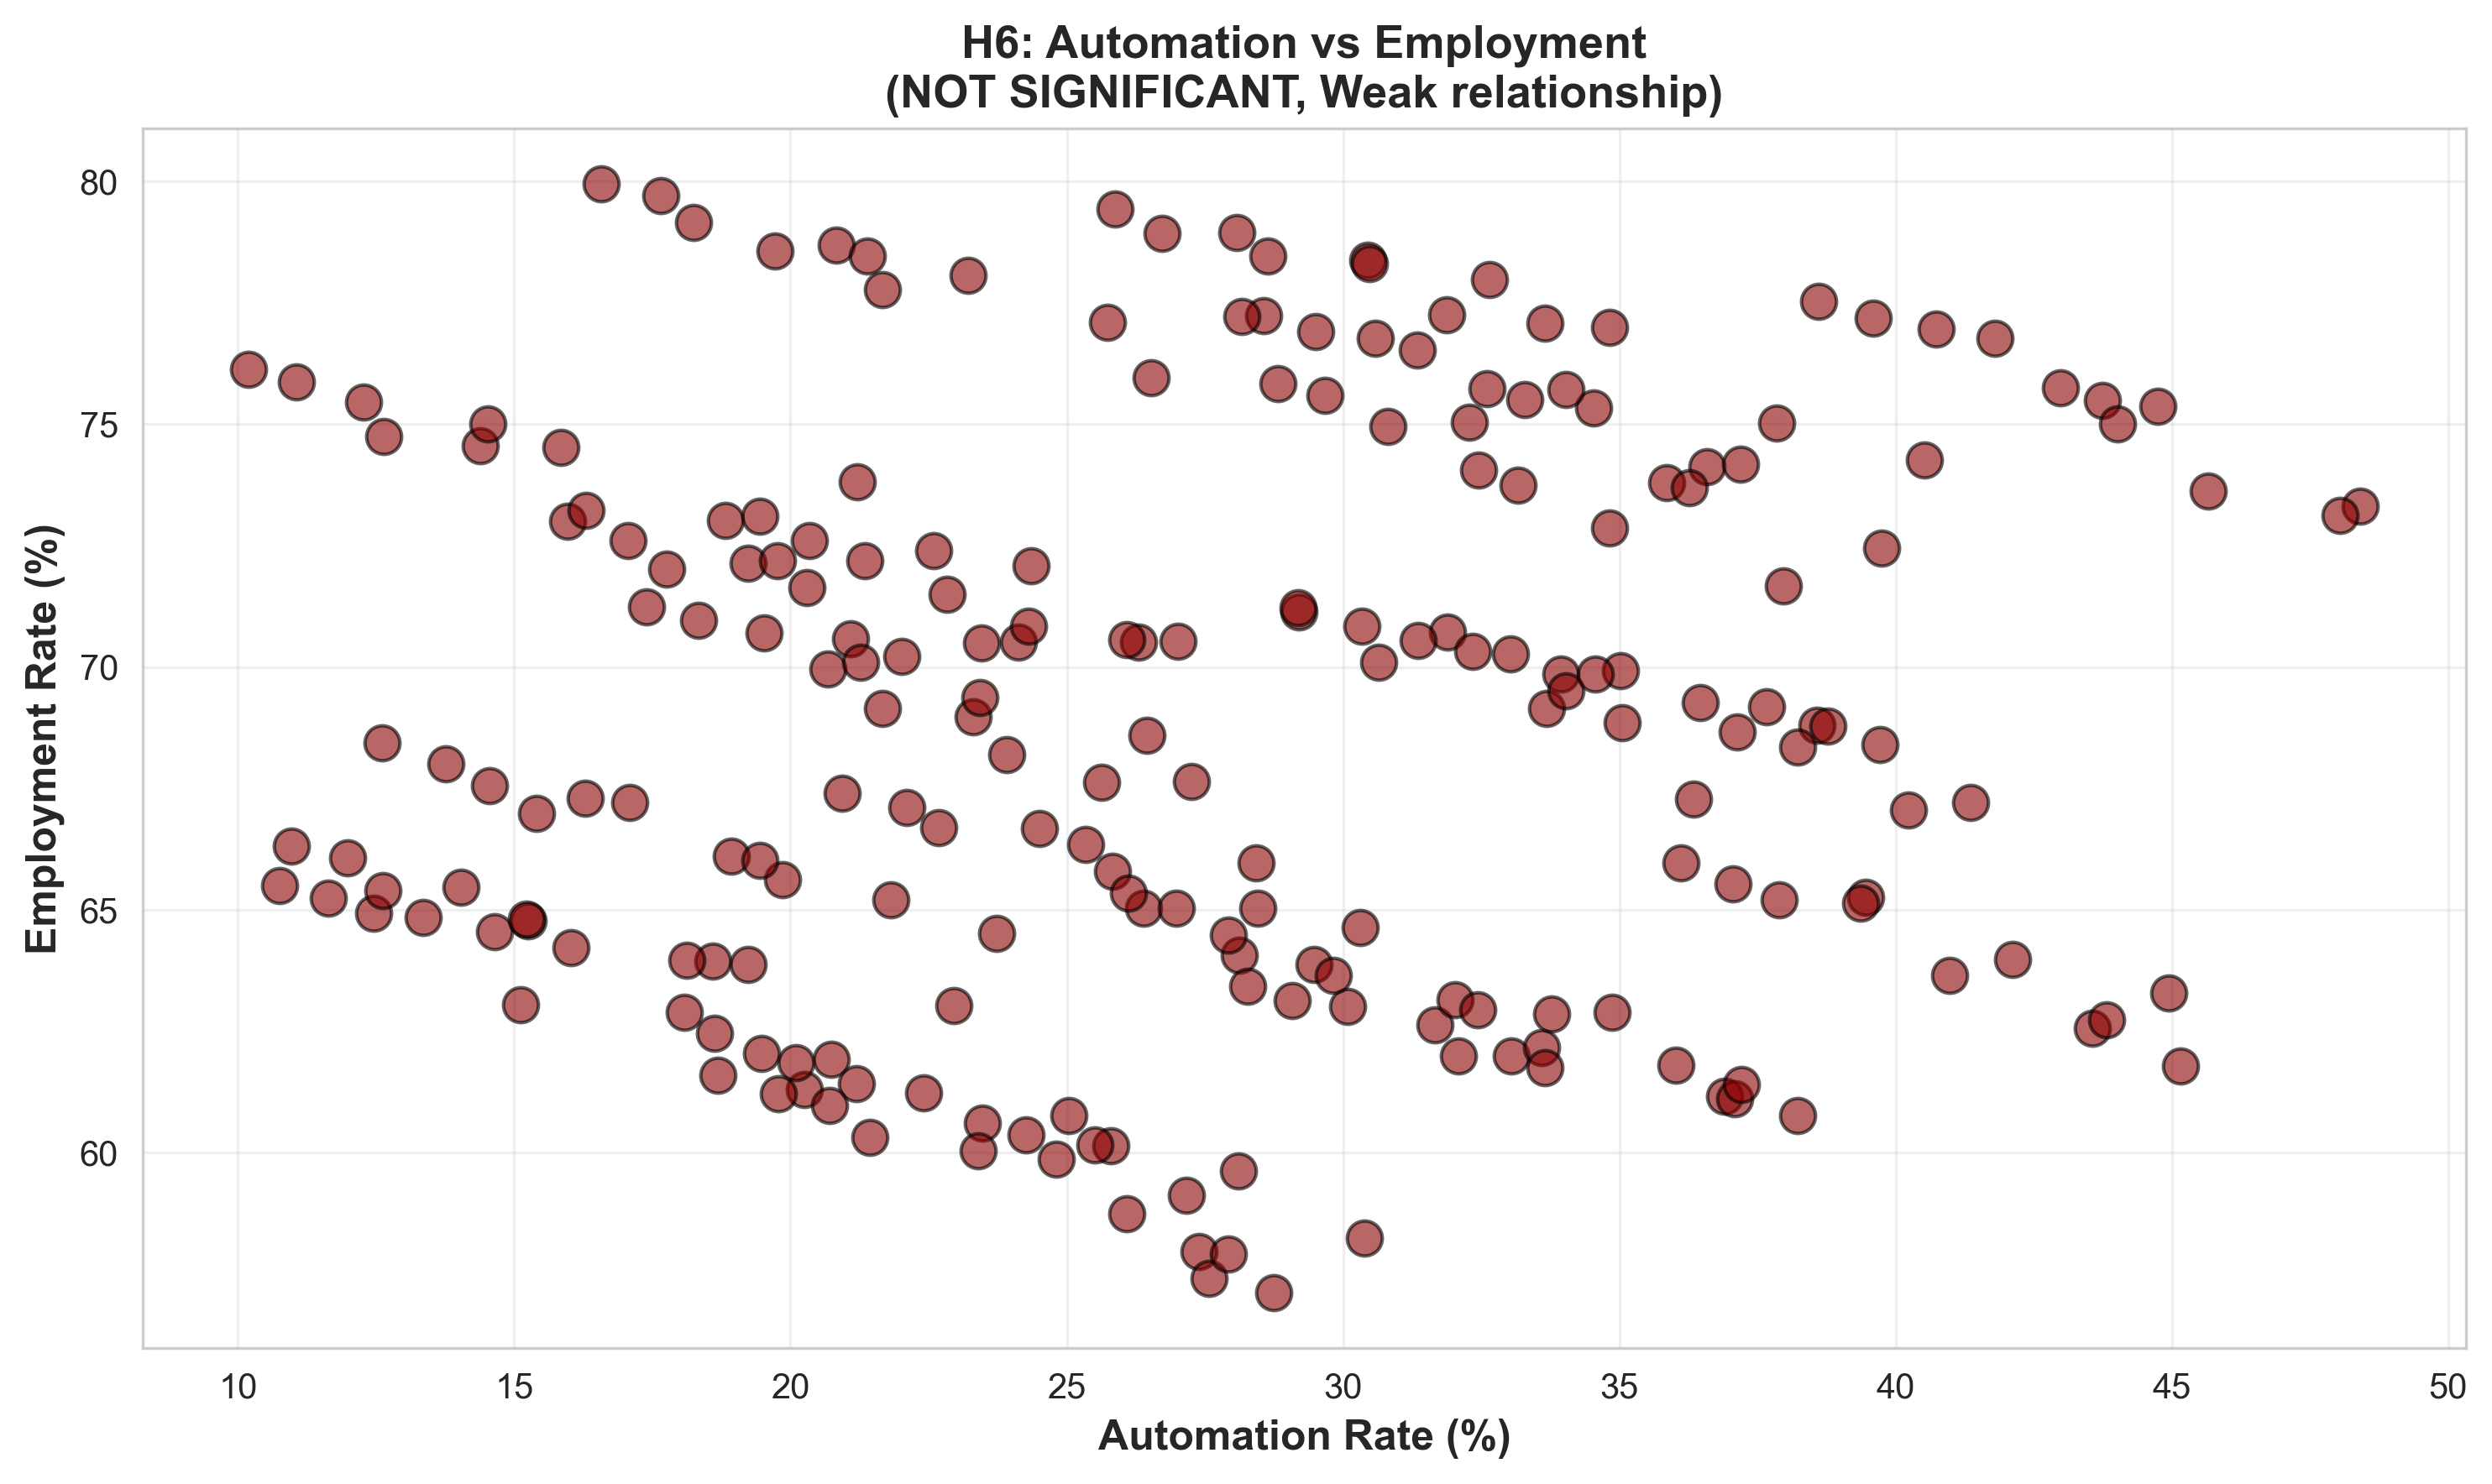

In [31]:
from IPython.display import Image, display

viz_files = [
    '../visualizations/01_h1_ai_assistance_satisfaction.png',
    '../visualizations/02_h2_outcome_satisfaction.png',
    '../visualizations/03_h3_tasktype_session.png',
    '../visualizations/04_h4_outcome_satisfaction.png',
    '../visualizations/05_h5_ai_investment_trend.png',
    '../visualizations/06_h5_investment_job_creation.png',
    '../visualizations/07_h6_automation_employment.png',
]

for viz_file in viz_files:
    display(Image(viz_file))
